# 更好的手动特征工程
虽然featuretools提供了自动特征工程，但是dfs巨慢，这让人头疼。

这促使我寻找更好的自动或者手动方式。


参考Feature Selection with Null Importances
- 有效特征面对假标签表现得应该很差
- 无效特征面对真假标签表现得差不多

[手动特征工程](https://www.kaggle.com/code/ogrellier/lighgbm-with-selected-features/script)

我们可以用将标签不断打散，每次lgbm计算特征，就可以识别出无效特征了

以apptrain开始

In [2]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from lightgbm import LGBMClassifier
import warnings
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

In [ ]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')

In [ ]:
train_labels = application_train['TARGET']
train_ids = application_train['SK_ID_CURR']
test_ids = application_test['SK_ID_CURR']
train_features = application_train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = application_test.drop(columns=['SK_ID_CURR'])

In [ ]:
for col in train_features.select_dtypes(include=['object']).columns:
    train_features[col] = train_features[col].astype('category')

for col in test_features.select_dtypes(include=['object']).columns:
    test_features[col] = test_features[col].astype('category')

## null importance

In [ ]:
def get_features_importance(train_features, train_labels):
    lgbm_model = LGBMClassifier(
        n_estimators=100,      
        learning_rate=0.1, 
        max_depth=8,      
        random_state=42,   
    )
    lgbm_model.fit(train_features, train_labels)
    features_importance = pd.DataFrame(
        {
            'gain': lgbm_model.booster_.feature_importance(importance_type='gain'),
            'split': lgbm_model.booster_.feature_importance(importance_type='split'),
            'feature': lgbm_model.feature_name_
        }
    )
    return features_importance

In [ ]:
actual_fi_df = get_features_importance(train_features, train_labels)

多次shuffle
- pd没有这个函数， 使用`.sample(frac=1)` 全采样
  - 这个服从正太分布采用

In [ ]:
runs = 50
fi_list = []
for i in range(runs):
    shuffle_train_labels = train_labels.sample(frac=1)
    fi_df = get_features_importance(train_features, shuffle_train_labels)
    fi_df['run'] = i + 1
    fi_list.append(fi_df)

In [ ]:
fi_dfs = pd.concat(fi_list, axis=0, ignore_index=True)

我们可以绘制 这些重要性得分布，
- 如果真实重要性与随机重要性相近，那就是假特征

In [ ]:
actual_fi_df.sort_values(by='gain')

In [ ]:
def plot_importance_distribution_of_feature(actual_fi_df, df, feature_name):
    data = df[df['feature'] == feature_name]
    
    actual_gain = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'gain'].iloc[0]
    actual_split = actual_fi_df.loc[actual_fi_df['feature'] == feature_name, 'split'].iloc[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    sns.histplot(data['gain'], alpha=0.3, label='Null Gain', ax=ax1, kde=True)
    ax1.axvline(x=actual_gain,  linestyle='--', label=f'Actual: {actual_gain:.1f}')
    ax1.set_title(f'Gain Importance: {feature_name}')
    ax1.legend()
    
    sns.histplot(data['split'],  alpha=0.3, label='Null Split', ax=ax2, kde=True)
    ax2.axvline(x=actual_split,  linestyle='--', label=f'Actual: {actual_split}')
    ax2.set_title(f'Split Importance: {feature_name}')
    ax2.legend()
    
    plt.tight_layout()


In [ ]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'FONDKAPREMONT_MODE')

In [ ]:
plot_importance_distribution_of_feature(actual_fi_df, fi_dfs, 'EXT_SOURCE_3')

我们以分布得75分位数 作为 分布值， 去与真实对比。
- 如果大于这个值，表示真实特征表现优于75%的噪声
  - 即 score>0 。 我们使用log以0分界，可以更好的剔除

In [ ]:
def get_feature_score(actual_importance, shuffle_importances, feature_name):
    feature_actual_gain = actual_importance[actual_importance['feature'] == feature_name]['gain']
    feature_actual_split = actual_importance[actual_importance['feature'] == feature_name]['split']
    feature_shuffle_gains = shuffle_importances[shuffle_importances['feature'] == feature_name]['gain']
    feature_shuffle_splits = shuffle_importances[shuffle_importances['feature'] == feature_name]['split']
    return pd.DataFrame({
        'feature': feature_name,
        'gain_score':  np.log(1e-10 + feature_actual_gain / np.percentile(feature_shuffle_gains, 75)),
        'split_score': np.log(1e-10 + feature_actual_split / np.percentile(feature_shuffle_splits, 75)),
    })

In [ ]:
get_feature_score(actual_fi_df, fi_dfs, 'CODE_GENDER')

In [ ]:
features_score = []
for f in actual_fi_df['feature'].unique():
    features_score.append(get_feature_score(actual_fi_df, fi_dfs, f))

In [ ]:
features_score = pd.concat(features_score, ignore_index=True)

In [ ]:
plot_gain_features_score = features_score.sort_values(by='gain_score', ascending=False)
plot_split_features_score = features_score.sort_values(by='split_score', ascending=False)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

sns.barplot(data=plot_gain_features_score.head(70), x='gain_score', y='feature', ax=axes[0])
axes[0].set_title('Top 70 Features by Gain')

sns.barplot(data=plot_split_features_score.head(70), x='split_score', y='feature', ax=axes[1])
axes[1].set_title('Top 70 Features by Split')

plt.tight_layout()

In [ ]:
features_score.head()

In [ ]:
threshold = 30
features_removed_by_gain_score = features_score[features_score['gain_score'] < 0]
features_removed_by_split_score = features_score[features_score['split_score'] < 0]
features_removed = set(features_removed_by_gain_score['feature']) & set(features_removed_by_split_score['feature'])

In [ ]:
features_removed

In [ ]:
train_features_clean = train_features.drop(columns=features_removed)
test_features_clean = test_features.drop(columns=features_removed)

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators=100,      
    learning_rate=0.1, 
    max_depth=8,      
    random_state=42,   
)
lgbm_model.fit(train_features_clean, train_labels)

In [ ]:
train_pred = lgbm_model.predict_proba(train_features_clean)
roc_auc_score(train_labels, train_pred[:, 1])

In [ ]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


## 手动特征工程
相比之前手动特征工程，我们会构造更多的领域特征

In [6]:
plt.rcParams['figure.figsize'] = (8,6) 
plt.rcParams['figure.dpi'] = 100

### application_train/test

In [4]:
nrows = None
app_train = pd.read_csv('data/application_train.csv', nrows=nrows)
app_test = pd.read_csv('data/application_test.csv', nrows=nrows)
print(f'train {len(app_train)}, test {len(app_test)}')
app = pd.concat([app_train, app_test])
app = app.reset_index()
print(f'app {len(app)}')

train 307511, test 48744
app 356255


#### CODE_GENDER

概率柱状图。
- 高度表示， 违约人数/总人数。 

In [ ]:
sns.barplot(data=app, x='CODE_GENDER',y='TARGET')

In [ ]:
app = app[app['CODE_GENDER'] != 'XNA']
print(app.shape)

#### DAYS_BIRTH
- 岁数分组

In [ ]:
min_age, max_age = (app['DAYS_BIRTH'] / -365).min(), (app['DAYS_BIRTH'] / -365).max()
print(f'birth min age:{min_age}, max age: {max_age}')

In [ ]:
app['NEW_AGE_BIN']= pd.cut(app['DAYS_BIRTH'] / -365, bins=np.linspace(20, 70, 11))

In [ ]:
sns.barplot(data=app, x= 'NEW_AGE_BIN', y = 'TARGET')
plt.title('各年龄段的违约率')
plt.tight_layout()

随着年龄增加，违约率逐渐降低

#### DAYS_REGISTRATION
- 户口本更新时间
- 更新时间离得越远，人越稳定
- 与年龄 比率，  比例越大越稳定
- 着重标识最近一年修改的

In [ ]:
app['NEW_YEARS_REGISTRATION'] = app['DAYS_REGISTRATION'] / -365

In [ ]:
app['NEW_REGISTRATION_TO_AGE_RATIO'] = app['DAYS_REGISTRATION'] / app['DAYS_BIRTH']

In [ ]:
sns.kdeplot(data=app, x='NEW_REGISTRATION_TO_AGE_RATIO', hue='TARGET', common_norm = False)

最近一年内更新户口居住地址

In [ ]:
app['FLAG_1year_RECENT_REGISTRATION_CHANGE'] = (app['DAYS_REGISTRATION'] > -365).astype(int)

In [ ]:
sns.barplot(data=app, x='FLAG_1year_RECENT_REGISTRATION_CHANGE', y='TARGET')
plt.title('最近一年更新居住地址')

最近更新户口居住地址的人可能违约概率大。

In [ ]:
app['RECENT_3month_REGISTRATION_CHANGE'] = (app['DAYS_REGISTRATION'] > -31).astype(int)

In [ ]:
sns.barplot(data=app, x='RECENT_3month_REGISTRATION_CHANGE', y='TARGET')
plt.title('最近3个月更新居住地址')

#### DAYS_ID_PUBLISH

和DAYS_REGISTRATION强相关嘛？

In [ ]:
app[['DAYS_ID_PUBLISH', 'DAYS_BIRTH']].corr()

相关性不强，我们需要单独处理

In [ ]:
app['YEAR_ID_PUBLISH'] = app['DAYS_ID_PUBLISH']/-365
sns.kdeplot(data = app, x='YEAR_ID_PUBLISH', hue='TARGET', common_norm=False)
plt.title('身份证更新年限')

我们构造一个新特征，标识

In [ ]:
app['DAYS_DIFF_ID_REG'] = app['DAYS_ID_PUBLISH'] - app['DAYS_REGISTRATION']
sns.kdeplot(data = app, x = 'DAYS_DIFF_ID_REG', hue='TARGET', common_norm=False)
plt.title('身份证更新与居住地更新差值')

#### DAYS_LAST_PHONE_CHANGE

In [7]:
app['PHONE_CHANGE_DAYS'] = app['DAYS_LAST_PHONE_CHANGE'].abs()

In [8]:
app['PHONE_CHANGE_BIN'] = pd.cut(app['PHONE_CHANGE_DAYS'], bins=[0, 10, 30, 60, 180, 365, 730, 1095, 4000])

In [16]:
def plot_category_stat(data, feature, target='TARGET'):
    """ 分类特征 计数、违约率、缺失值多少， 双轴图
    可以看到长尾
    """
    temp_data = data[[feature, target]].copy()

    percent = temp_data[feature].isnull().mean() * 100
    print(f'>>> {feature} has {percent:.2f}% missing values!')

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 按照计数从高到低
    sns.countplot(x=feature, data=temp_data, ax=ax1, color='lightgray', alpha=0.5,        )
    ax1.set_ylabel('样本总数 (Count)', fontsize=12)
    ax1.set_title(f'{feature} 的数量与违约率综合分析', fontsize=15)

    ax2 = ax1.twinx()
    sns.pointplot(x=feature, y=target, data=temp_data, ax=ax2, color='red',)
    ax2.set_ylabel('平均违约率 (Target Mean)', color='red', fontsize=12)
    
    plt.tight_layout()
    plt.show()

PHONE_CHANGE_BIN has 12.22% missing values!


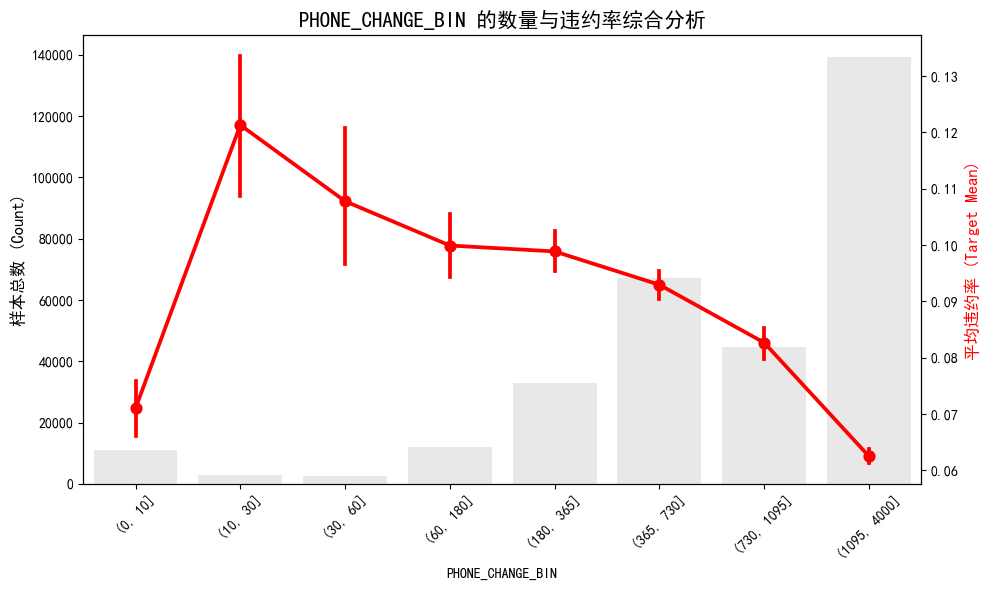

In [27]:
plot_category_stat(app, 'PHONE_CHANGE_BIN')

我们可以看到哪些最近更新手机号的人，确实往往具有更高的违约率.


#### FLAG_MOBIL，FLAG_EMP_PHONE，FLAG_WORK_PHONE，FLAG_CONT_MOBILE，FLAG_PHONE，FLAG_EMAIL

1. 我们可以将这个联系方式组合为一个特征。组合时候应该有权重
2. 一个人必须有FLAG_MOBIL

In [ ]:
app['CONTACT_SCORE'] = app['FLAG_EMAIL'] + app['FLAG_WORK_PHONE']  + app['FLAG_PHONE'] * 1 + app['FLAG_CONT_MOBILE'] + app['FLAG_EMP_PHONE'] 

In [ ]:
fig, axes = plt.subplots(3,2, figsize=(9,10), sharex=True, sharey = True)
axes = axes.flatten()
contact_cols =  ['FLAG_EMAIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 
                'FLAG_CONT_MOBILE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE']
for i,col in enumerate(contact_cols):
    sns.barplot(data=app, x=col, y='TARGET', ax=axes[i])
    axes[i].set_title(f'Target Mean by {col}')
    axes[i].set_ylim(0, 0.12) # 统一 y 轴刻度，方便横向对比“谁的柱子更高

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=app, x='CONTACT_SCORE', hue = 'TARGET', common_norm=False)


这些特征都没有用，都不需要。组合起来也看不出什么。

#### NAME_EDUCATION_TYPE

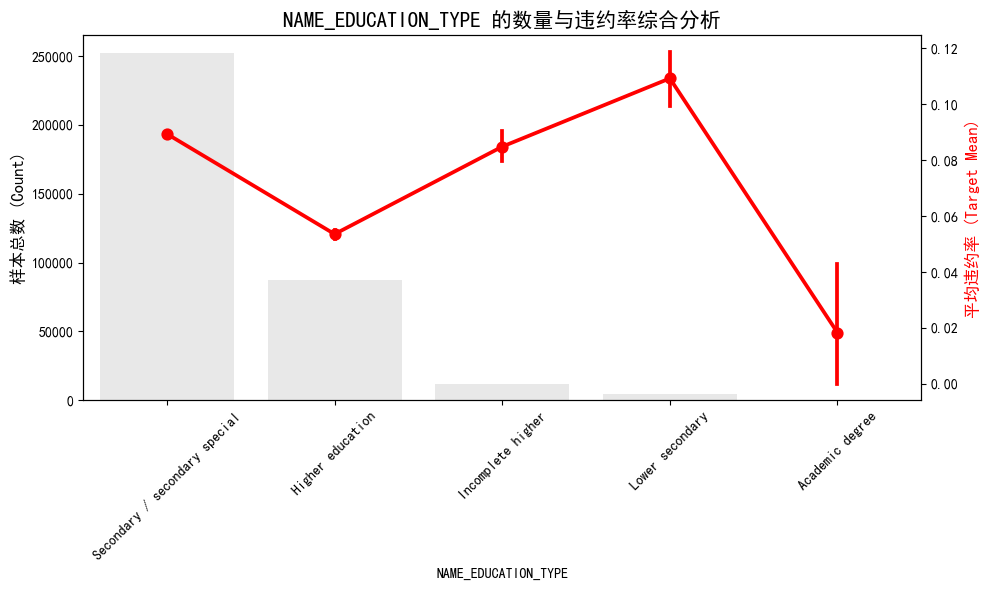

In [43]:
plot_category_stat(app, 'NAME_EDUCATION_TYPE')

1. 具有长尾。
2. 初中学历作为最低学历，却具备最大违约率； 博士学位作为最高学历，具备最低违约率；
3. 这是一个**有序**的特征，显然，学历越高违约率越低

In [59]:
app['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    252379
Higher education                  87379
Incomplete higher                 12001
Lower secondary                    4291
Academic degree                     205
Name: count, dtype: int64

In [60]:
app['NAME_EDUCATION_TYPE'] = app['NAME_EDUCATION_TYPE'].map({
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
})
app['EDUCATION_ORDINAL'] = app['NAME_EDUCATION_TYPE'].fillna(0)

#### FLAG_OWN_CAR

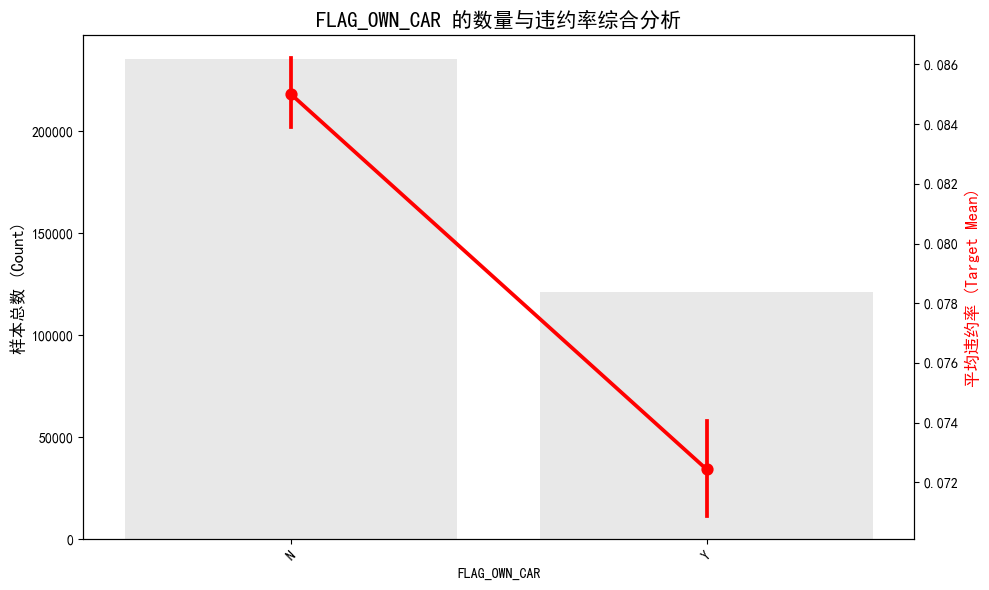

In [62]:
plot_category_stat(app, 'FLAG_OWN_CAR')

有车的违约率更低

In [66]:
app['NEW_FLAG_OWN_CAR'] = app['FLAG_OWN_CAR'].map({
    'N': 0,
    'Y': 1,
})

In [67]:
app['NEW_FLAG_OWN_CAR'].value_counts()

NEW_FLAG_OWN_CAR
0    235235
1    121020
Name: count, dtype: int64

#### OWN_CAR_AGE

<Axes: xlabel='OWN_CAR_AGE', ylabel='Density'>

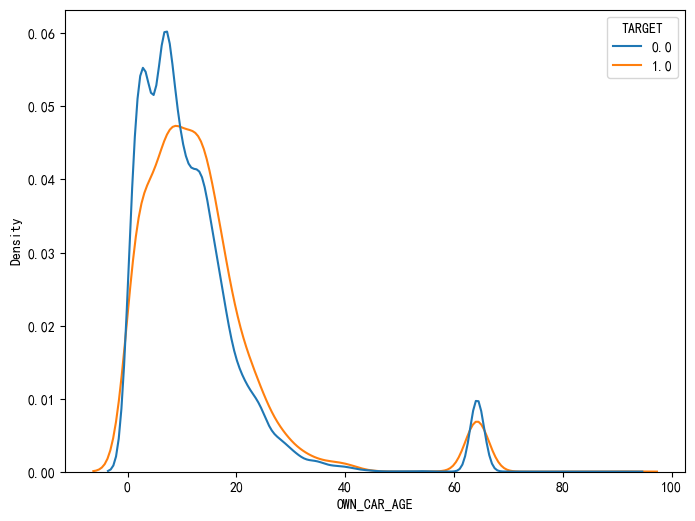

In [74]:
sns.kdeplot(data=app, x='OWN_CAR_AGE', hue='TARGET', common_norm=False)

看起来没什么区别， 但是右边的长尾效应和异常值 把左边压扁了

<Axes: xlabel='OWN_CAR_AGE', ylabel='Count'>

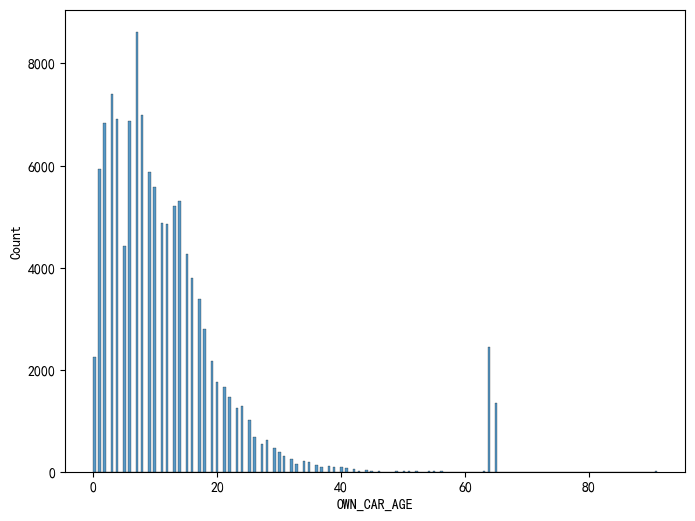

In [72]:
sns.histplot(data=app, x='OWN_CAR_AGE')

1. 老爷车60-90年算异常数据嘛？
- 不能，因为显然具有特征意义。
- 一方面，拿出一个新特征，来标识； 另一方面，通过clip到35年，去掉长尾效应

In [84]:
app['INTER_OWN_CAR_AGE'] = app['OWN_CAR_AGE'].clip(upper=35)
app['NEW_IS_OLD_CAR'] = app['OWN_CAR_AGE'] > 60

In [88]:
app['NEW_CAR_AGE_BIN'] = pd.cut(app['INTER_OWN_CAR_AGE'], bins=[0, 1, 3, 5, 7, 10, 15,20, 35])

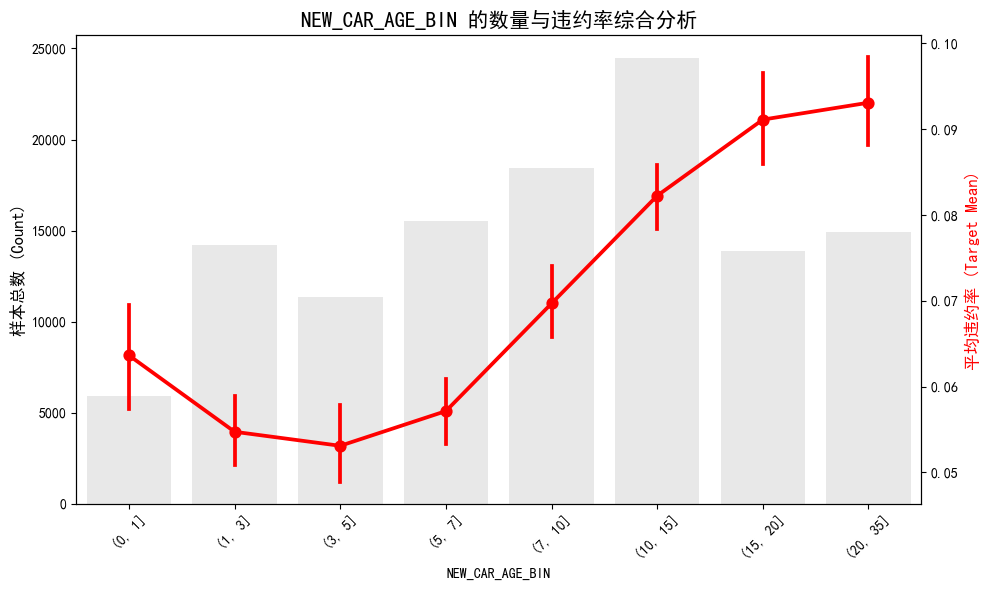

In [89]:
plot_category_stat(app, 'NEW_CAR_AGE_BIN')

- 总体来说，汽车年限越高， 违约率越高.
- 刚买3年内的车，违约率也会高点

#### 房屋评价得分
- 对于房屋详细的特征，他们不重要。我们不要一个个处理！
1. 尝试构建房屋评分
2. 只采用mode
3. 挑几个关键特征

##### FLAG_OWN_REALTY

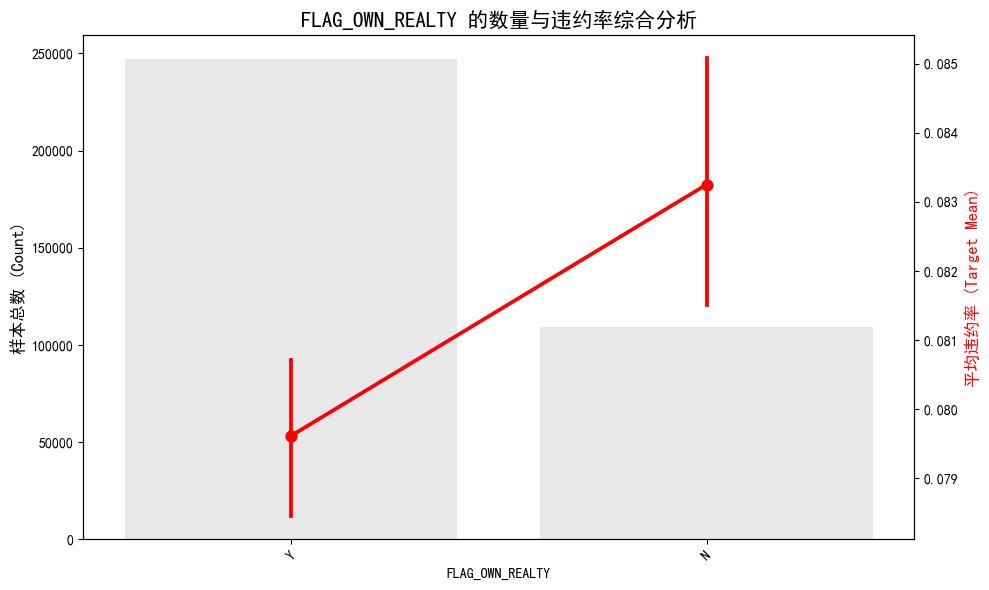

In [ ]:
plot_category_stat(app, 'FLAG_OWN_REALTY')

- 就是没房的违约率更高

##### TOTALAREA_MODE

<Axes: xlabel='TOTALAREA_MODE', ylabel='Density'>

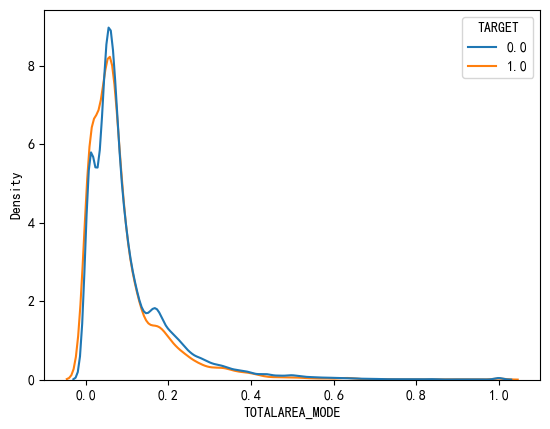

In [ ]:
sns.kdeplot(data=app, x='TOTALAREA_MODE', hue='TARGET', common_norm=False)

#### 地区住址
- 通过求和描述一个人 居住地 工作地 老家 的稳定性

In [ ]:
app['INTER_LOCATION_INCONSISTENT_COUNT'] = (app['REG_CITY_NOT_LIVE_CITY'] + 
                                          app['REG_CITY_NOT_WORK_CITY'] + 
                                          app['LIVE_CITY_NOT_WORK_CITY'] + 
                                          app['REG_REGION_NOT_LIVE_REGION']+
                                          app['REG_REGION_NOT_WORK_REGION'] +
                                          app['LIVE_REGION_NOT_WORK_REGION']
                                          )

>>> NEW_LOCATION_INCONSISTENT_COUNT has 0.00% missing values!


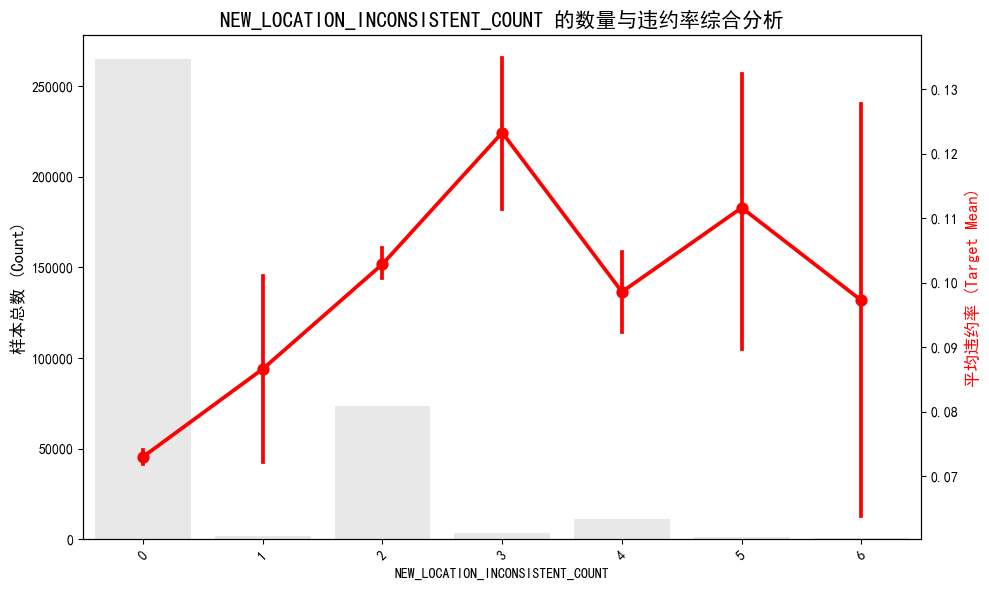

In [ ]:
plot_category_stat(app, 'INTER_LOCATION_INCONSISTENT_COUNT')

- 那些非0的值，往往确实更加具备更高违约率

In [46]:
app['INTER_REGION_POPULATION_BIN'] = pd.cut(app['REGION_POPULATION_RELATIVE'], bins=10)

>>> INTER_REGION_POPULATION_BIN has 0.00% missing values!


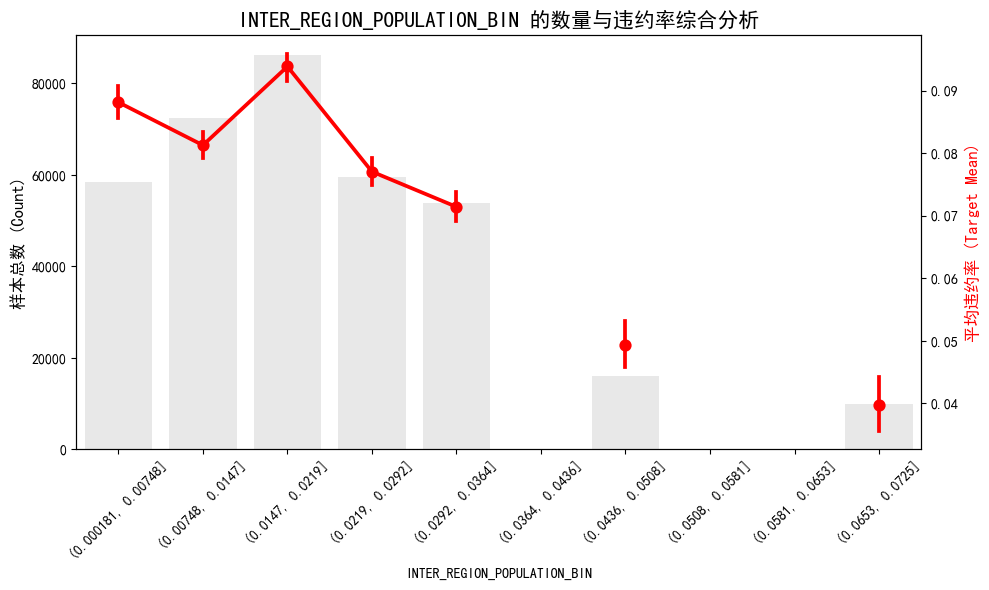

In [47]:
plot_category_stat(app, 'INTER_REGION_POPULATION_BIN')

- 依然是通过bin分桶，能够看到局部之间的下降趋势。地区密度越大（大城市），违约率越低。

对于地区和城市评级，我们通过diff构造

In [54]:
app['INTER_REGION_RATING_DIFF'] = app['REGION_RATING_CLIENT_W_CITY'] - app['REGION_RATING_CLIENT']

>>> INTER_REGION_RATING_DIFF has 0.00% missing values!


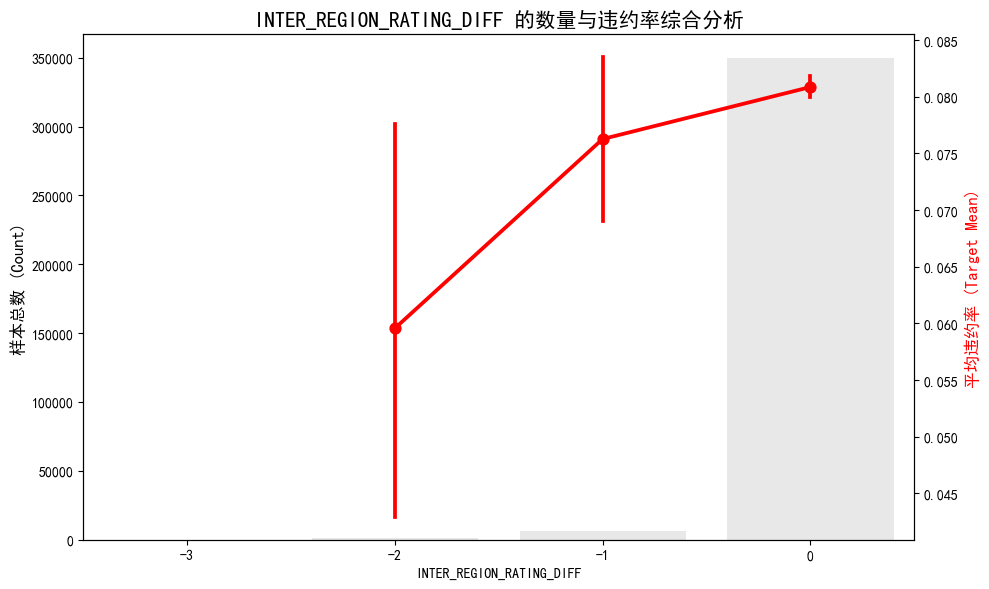

In [55]:
plot_category_stat(app, 'INTER_REGION_RATING_DIFF')

- 分类数过少。极度不平均
- 极端的类并未展示出极端的违约率。
不采用

#### 社交圈

1050

1050

In [58]:
app[['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE']].corr()

,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE
OBS_30_CNT_SOCIAL_CIRCLE,1.000000,0.998768
OBS_60_CNT_SOCIAL_CIRCLE,0.998768,1.000000


- 相关性太高了。我们只采用60天的数据
- "近朱者赤，近墨者黑"， DEF逾期人数更加重要
- 我们假设这个人有100人朋友圈，DEF/OBS表示 这个朋友圈坏账率

<Axes: >

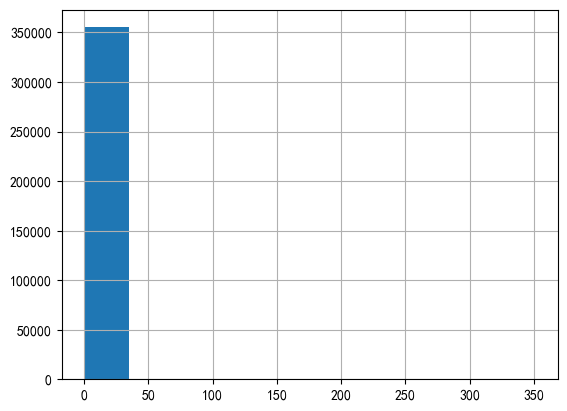

In [64]:
app['OBS_60_CNT_SOCIAL_CIRCLE'].hist()

clip去掉长尾噪声，

In [69]:
app['OBS_60_CNT_SOCIAL_CIRCLE'] = app['OBS_60_CNT_SOCIAL_CIRCLE'].clip(upper=12)

<Axes: >

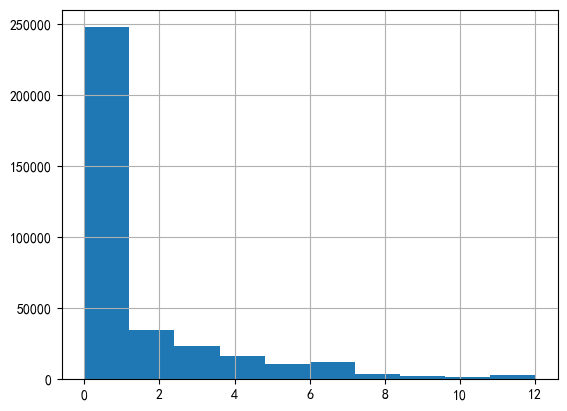

In [70]:
app['OBS_60_CNT_SOCIAL_CIRCLE'].hist()

In [72]:
app['DEF_60_CNT_SOCIAL_CIRCLE']= app['DEF_60_CNT_SOCIAL_CIRCLE'].clip(upper=5)

<Axes: >

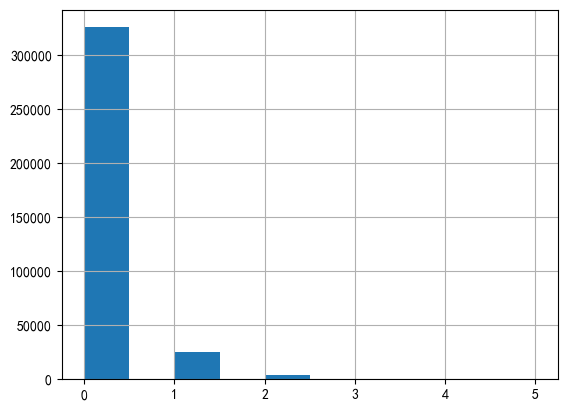

In [73]:
app['DEF_60_CNT_SOCIAL_CIRCLE'].hist()

In [86]:
app['DEF_60_CNT_SOCIAL_CIRCLE'] = app['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0)
app['OBS_60_CNT_SOCIAL_CIRCLE'] = app['OBS_60_CNT_SOCIAL_CIRCLE'].fillna(0)

In [87]:
app['NEW_SOCIAL_RATIO_60'] = app['DEF_60_CNT_SOCIAL_CIRCLE']/(app['OBS_60_CNT_SOCIAL_CIRCLE'] + 1e-10)

In [90]:
app['NEW_SOCIAL_RATIO_60'].isnull().sum()

0

In [97]:
app['NEW_SOCIAL_BIN'] = pd.cut(app['NEW_SOCIAL_RATIO_60'], bins=[-0.1, 0.1,1, np.inf])

>>> NEW_SOCIAL_BIN has 0.00% missing values!


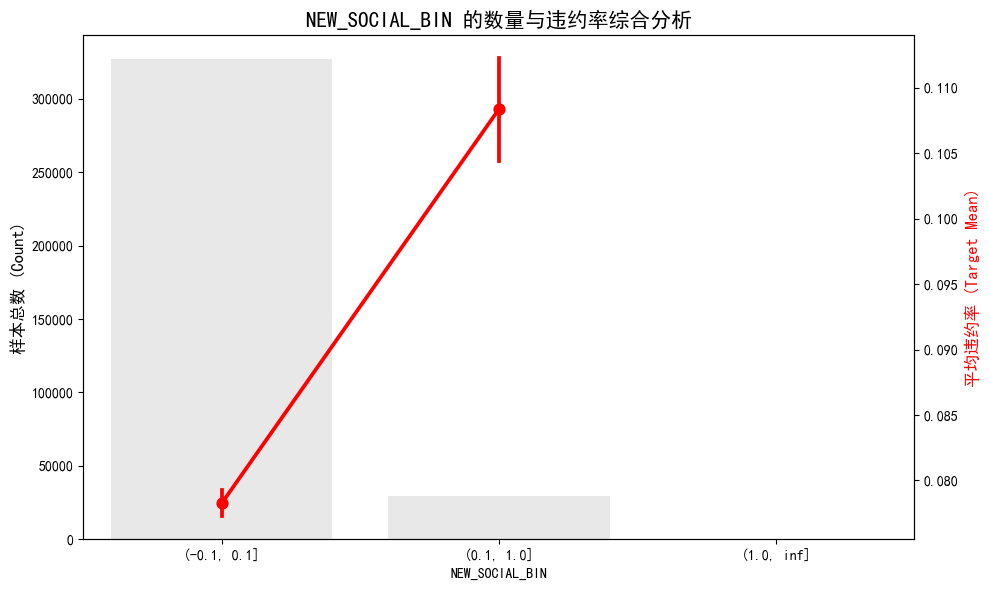

In [98]:
plot_category_stat(app, 'NEW_SOCIAL_BIN')

- 或许是有用的，这些少数的数据有着很高的违约率

#### 家庭

>>> NAME_FAMILY_STATUS has 0.00% missing values!


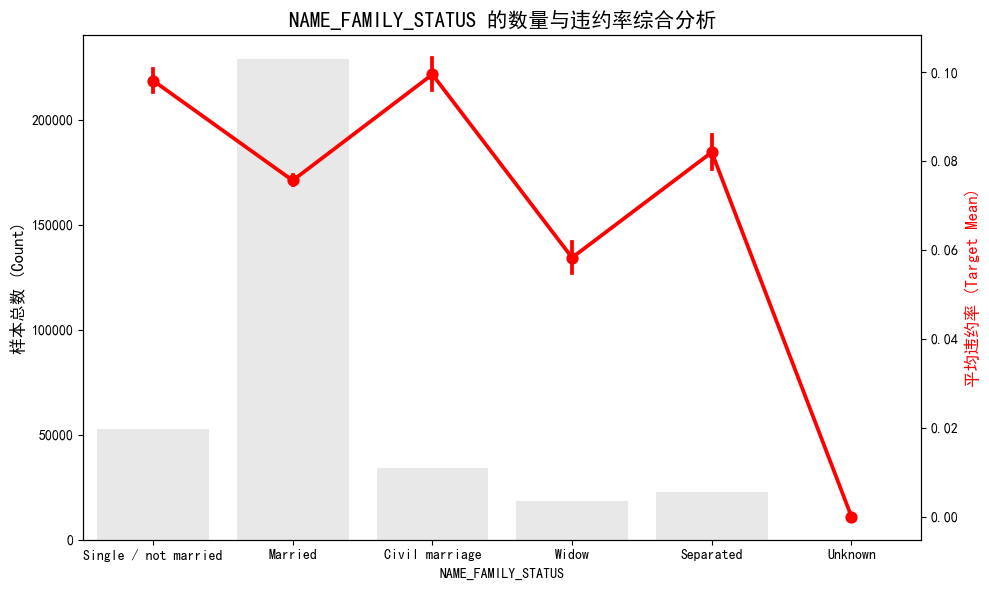

In [100]:
plot_category_stat(app, 'NAME_FAMILY_STATUS')

- 同居和单身的违约率比较高

In [103]:
app[['CNT_FAM_MEMBERS', 'CNT_CHILDREN']].corr()

,CNT_FAM_MEMBERS,CNT_CHILDREN
CNT_FAM_MEMBERS,1.000000,0.878912
CNT_CHILDREN,0.878912,1.000000


高度相关，保留一个

>>> CNT_CHILDREN has 0.00% missing values!


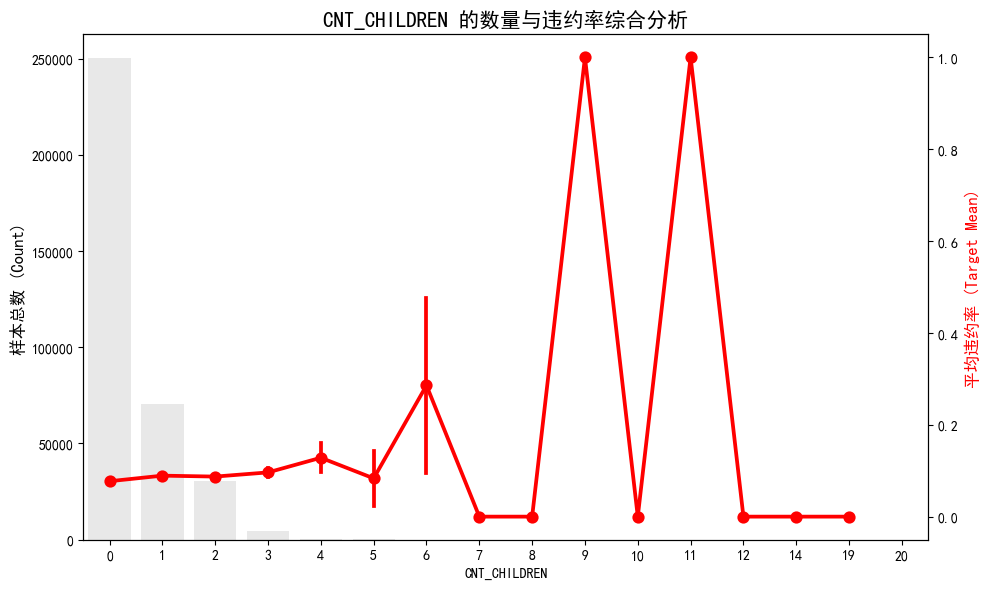

In [110]:
plot_category_stat(app, 'CNT_CHILDREN')

In [109]:
app['CNT_CHILDREN'].value_counts(normalize=True)

CNT_CHILDREN
0     0.701902
1     0.198237
2     0.086169
3     0.011935
4     0.001342
5     0.000269
6     0.000067
7     0.000022
8     0.000014
11    0.000008
14    0.000008
9     0.000006
12    0.000006
10    0.000006
19    0.000006
20    0.000003
Name: proportion, dtype: float64

In [111]:
app['NEW_FAM_CNT'] = app['CNT_CHILDREN'].clip(upper=3)

>>> NEW_FAM_CNT has 0.00% missing values!


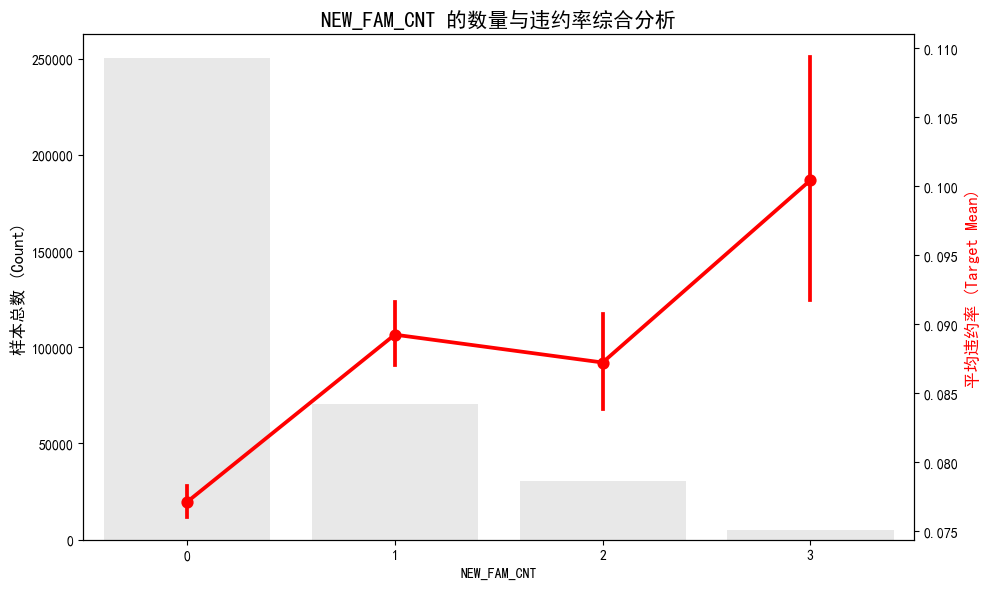

In [112]:
plot_category_stat(app, 'NEW_FAM_CNT')


#### 财务能力
- 负债收入比

In [124]:
app['AMT_INCOME_TOTAL'].sort_values()

1678          25650.0
20727         25650.0
186643        26100.0
240137        26100.0
246104        26100.0
             ...     
131127      6750000.0
77768       9000000.0
246858     13500000.0
203693     18000090.0
12840     117000000.0
Name: AMT_INCOME_TOTAL, Length: 356255, dtype: float64

<Axes: >

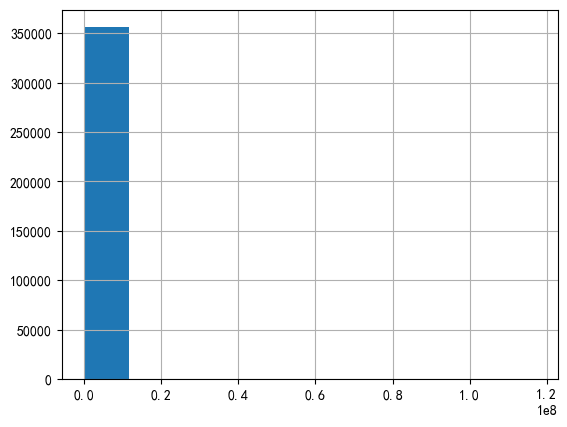

In [122]:
app['AMT_INCOME_TOTAL'].hist()

<Axes: >

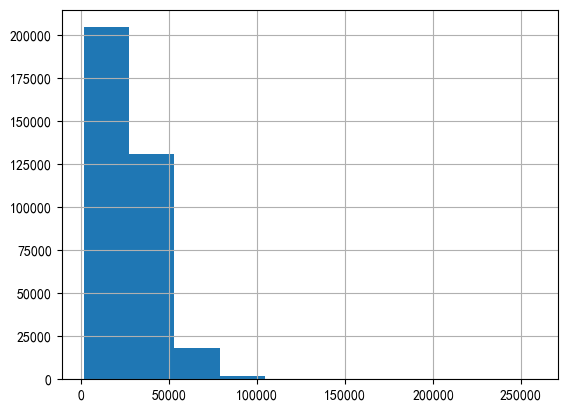

In [119]:
app['AMT_ANNUITY'].hist()

In [115]:
app['NEW_ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY']/app['AMT_INCOME_TOTAL']
app['NEW_ANNUITY_INCOME_RATIO_BIN'] = pd.cut(app['NEW_ANNUITY_INCOME_RATIO'], bins=[-0.1, 0.1, 0.2, 0.3, 0.5, 2])

>>> NEW_ANNUITY_INCOME_RATIO_BIN has 0.01% missing values!


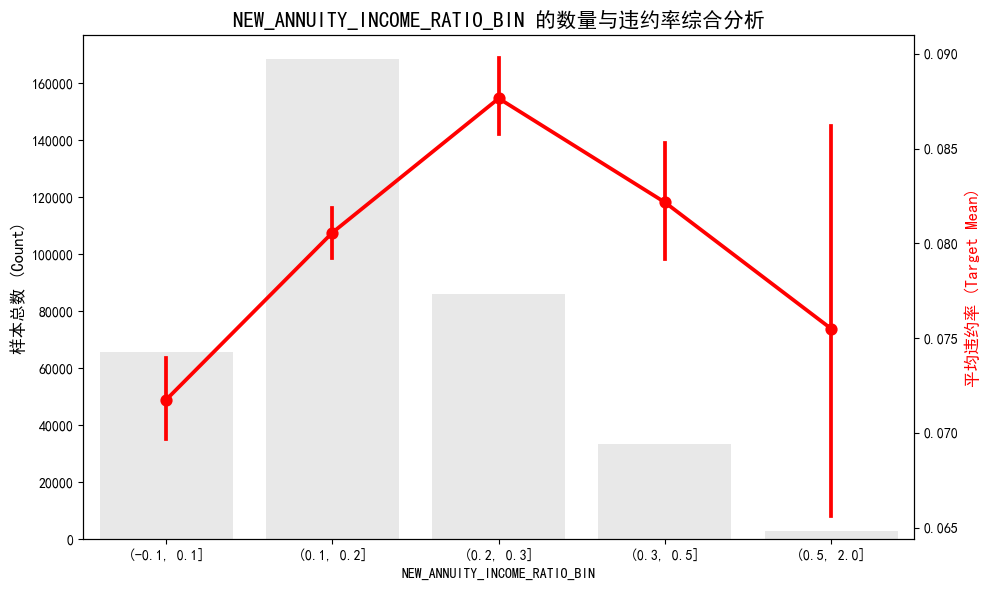

In [117]:
plot_category_stat(app,'NEW_ANNUITY_INCOME_RATIO_BIN' )

In [6]:
app[['AMT_ANNUITY','AMT_CREDIT']].corr()

,AMT_ANNUITY,AMT_CREDIT
AMT_ANNUITY,1.000000,0.762521
AMT_CREDIT,0.762521,1.000000


<Axes: xlabel='INTER_CREDIT_TO_ANNUITY', ylabel='Density'>

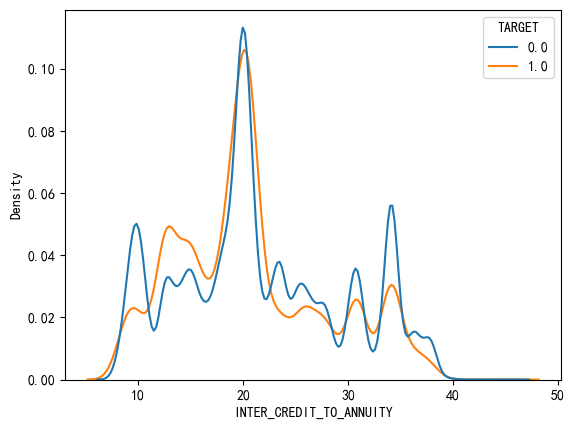

In [10]:
app['INTER_CREDIT_TO_ANNUITY']=app['AMT_CREDIT']/app['AMT_ANNUITY']
sns.kdeplot(data=app, x='INTER_CREDIT_TO_ANNUITY', hue='TARGET', common_norm=False)

- 近似于贷款期数

---

In [13]:
app['AMT_GOODS_PRICE'].isnull().sum()

278

In [14]:
app['NEW_CREDIT_TO_GOODS_RATIO'] = app['AMT_CREDIT'] / app['AMT_GOODS_PRICE']

<Axes: xlabel='NEW_CREDIT_TO_GOODS_RATIO', ylabel='Density'>

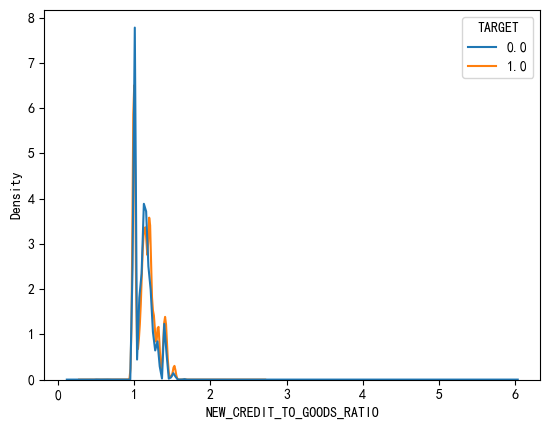

In [18]:
sns.kdeplot(data=app, x='NEW_CREDIT_TO_GOODS_RATIO', hue='TARGET', common_norm=False)

>>> NEW_CREDIT_TO_GOODS_RATIO_BIN has 0.08% missing values!


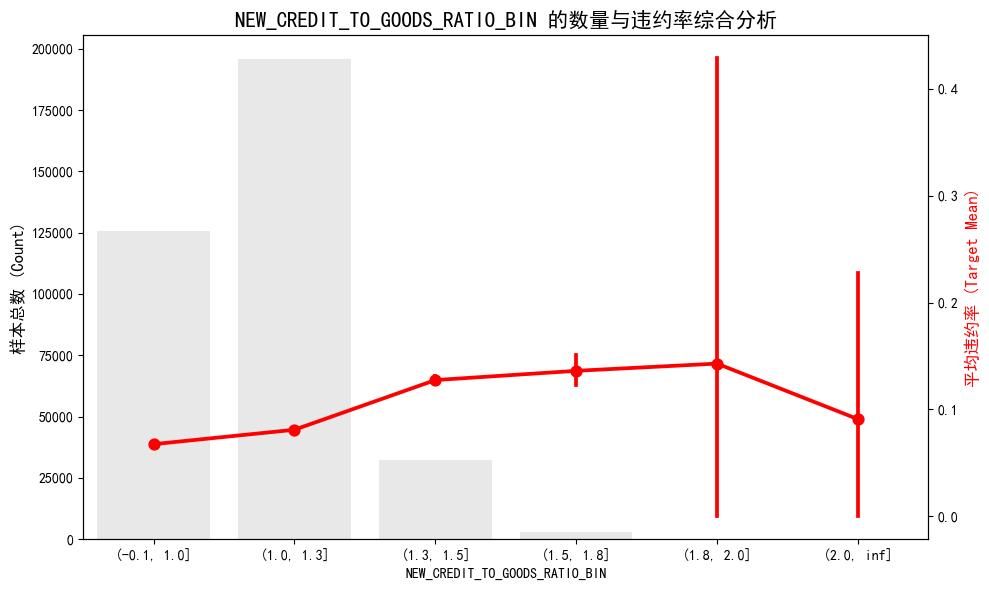

In [24]:
app['NEW_CREDIT_TO_GOODS_RATIO_BIN'] = pd.cut(app['NEW_CREDIT_TO_GOODS_RATIO'], bins=[-0.1, 1, 1.3, 1.5 ,1.8, 2,np.inf])
plot_category_stat(app, 'NEW_CREDIT_TO_GOODS_RATIO_BIN')

---

In [27]:
app['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Working                 183307
Commercial associate     83019
Pensioner                64635
State servant            25235
Unemployed                  23
Student                     20
Businessman                 11
Maternity leave              5
Name: count, dtype: int64

太少了，不具备特征意义

>>> NAME_INCOME_TYPE has 0.00% missing values!


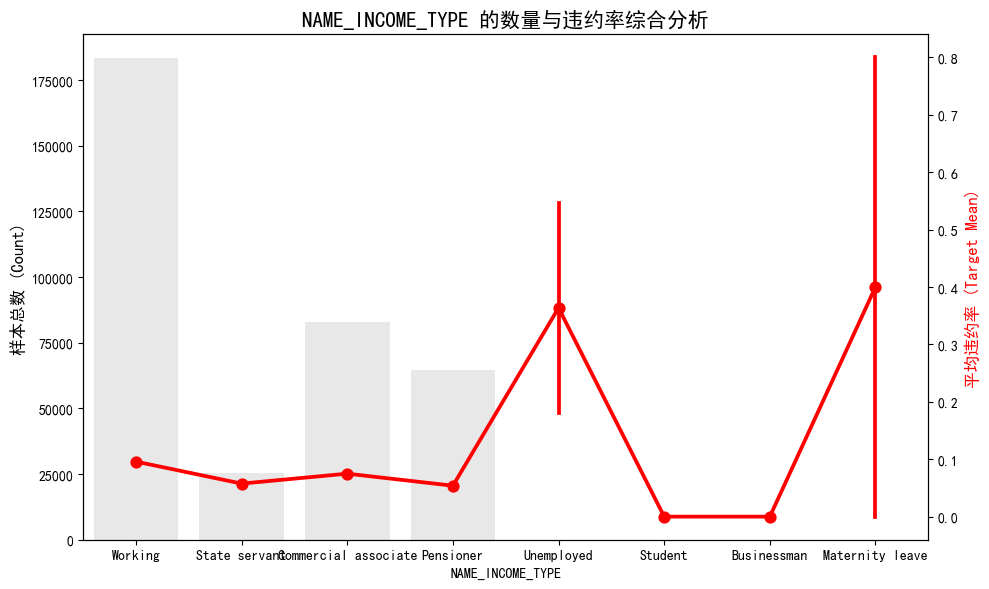

In [25]:
plot_category_stat(app, 'NAME_INCOME_TYPE')

---

In [29]:
app['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      316513
With parents            17074
Municipal apartment     12800
Rented apartment         5599
Office apartment         3024
Co-op apartment          1245
Name: count, dtype: int64

>>> NAME_HOUSING_TYPE has 0.00% missing values!


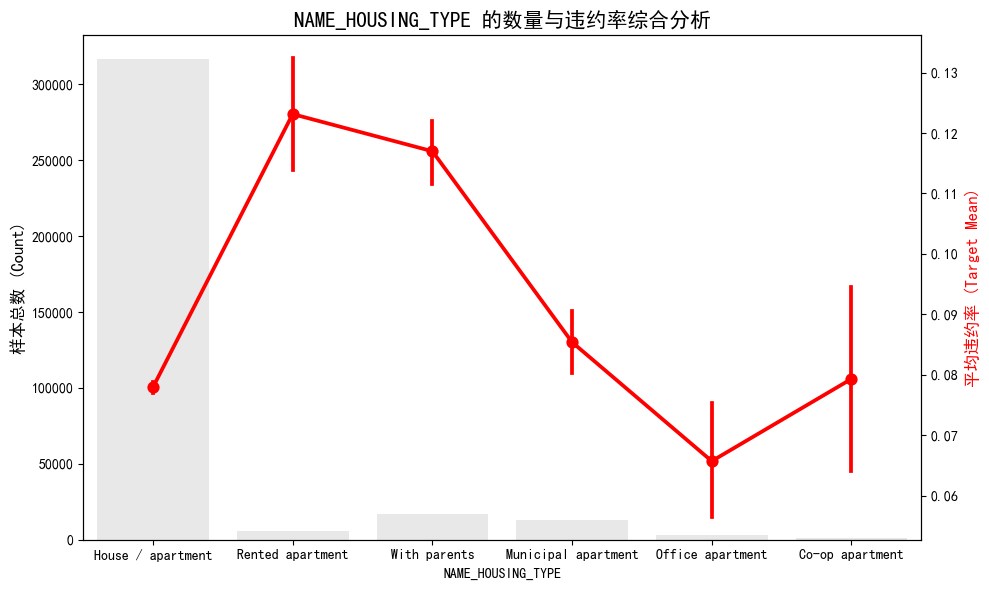

In [28]:
plot_category_stat(app,'NAME_HOUSING_TYPE')